# Veri Setinin Düzenlenmesi ve İncelenmesi

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("survey_results_public.csv") # 114 sütun 65 bin satırıımız var veri setimizde

In [18]:
df.head(5) 

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [19]:
# Veri setinde çok fazla sütun olduğu için birkaç sütun tutacağız çünkü kullanıcının 61 tane bilgi doldurması kullanıcıyı sıkabilir. 
# Tuttuğumuz sütunlar (Ülke , eğitim düzeyi , kaç yıldır meslekte , istihdam , ücret) 

# Years sütunu yıl bazında değişebiliyor: 'YearsCodePro' yoksa 'YearsCode' kullan
years_col = 'YearsCodePro' if 'YearsCodePro' in df.columns else ('YearsCode' if 'YearsCode' in df.columns else None)
if years_col is None:
    raise KeyError("Neither 'YearsCodePro' nor 'YearsCode' found in dataset.")

keep_cols = ["Country", "EdLevel", years_col, "Employment", "ConvertedCompYearly"]
df = df[keep_cols].copy()
df = df.rename({"ConvertedCompYearly": "Salary", years_col: "YearsCodePro"}, axis=1)
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary
0,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Employed,61256.0
1,Netherlands,"Associate degree (A.A., A.S., etc.)",10.0,Employed,104413.0
2,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,"Independent contractor, freelancer, or self-em...",53061.0
3,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Employed,36197.0
4,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,"Independent contractor, freelancer, or self-em...",60000.0


In [20]:
# Veri setinde çok fazla sütun olduğu için birkaç sütun tutacağız çünkü kullanıcının 61 tane bilgi doldurması kullanıcıyı sıkabilir. 
# Tuttuğumuz sütunlar (Ülke , eğitim düzeyi , kaç yıldır meslekte , istihdam , ücret) 

df = df[["Country" , "EdLevel" , "YearsCodePro"  , "Employment" , "Salary"]]
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary
0,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Employed,61256.0
1,Netherlands,"Associate degree (A.A., A.S., etc.)",10.0,Employed,104413.0
2,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,"Independent contractor, freelancer, or self-em...",53061.0
3,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Employed,36197.0
4,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,"Independent contractor, freelancer, or self-em...",60000.0


In [21]:
# Salary sütunumuzdaki NaN yani boş değerler içeren satırları veri setimizden çıkartacağız

df = df[df["Salary"].notnull()]
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary
0,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,Employed,61256.0
1,Netherlands,"Associate degree (A.A., A.S., etc.)",10.0,Employed,104413.0
2,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,"Independent contractor, freelancer, or self-em...",53061.0
3,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,Employed,36197.0
4,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,"Independent contractor, freelancer, or self-em...",60000.0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23928 entries, 0 to 49017
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       23928 non-null  object 
 1   EdLevel       23911 non-null  object 
 2   YearsCodePro  23819 non-null  float64
 3   Employment    23928 non-null  object 
 4   Salary        23928 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.1+ MB


In [23]:
# Veri setindeki boş değer içeren satırları çıkaracağız. Bunun yerine bu boş değerleri dolduradabilirdik ama zaten 23 binden fazla satırımız olduğu için çıkartmayı tercih ettik.

df = df.dropna()

In [24]:
# Sütunlara göre boş değer kalmadığını kontrol etmek için

df.isnull().sum()

Country         0
EdLevel         0
YearsCodePro    0
Employment      0
Salary          0
dtype: int64

In [25]:
df["Country"].value_counts()  # hangi ülkeden kaç kişinin verisi var

Country
United States of America                                5219
Germany                                                 2130
United Kingdom of Great Britain and Northern Ireland    1481
India                                                   1078
France                                                  1023
                                                        ... 
Djibouti                                                   1
Turkmenistan                                               1
Burundi                                                    1
Belize                                                     1
Guinea                                                     1
Name: count, Length: 164, dtype: int64

In [26]:
# Üstteki küçük ülkelerden kurtulmak istiyoruz (Solomon Islands , Guinea , Niger gibi) çünkü sadece 1 verinin olduğu ülkeleri ...
# ... kullanırsak bu modelimizin kafasını karıştırabilir (tek bir veriden bir şey öğrenemeyeceğinden). Bu ülkeleri "Other"da toplayacağız.
# Bunun için shorten_categories (Kategorileri Kısalt) fonksiyonunu yazdık.
# Burada ülkeden gelen örnek sayısı fonksiyona girdiğim eşik değerden (cutoff) büyükse buna dokunmuyoruz ama küçükse "Other"a ekliyoruz

def shorten_categories(categories, cutoff):
    categorical_map = {}
    for i in range(len(categories)):
        if categories.values[i] >= cutoff:
            categorical_map[categories.index[i]] = categories.index[i]
        else:
            categorical_map[categories.index[i]] = 'Other'
    return categorical_map


country_map = shorten_categories(df.Country.value_counts() , 400)
df["Country"] = df["Country"].map(country_map)
df.Country.value_counts()

# 400'den az verisi olanları "Other"a attık ve yeni "Country" sütunumuzu oluşturduk.

Country
Other                                                   6829
United States of America                                5219
Germany                                                 2130
United Kingdom of Great Britain and Northern Ireland    1481
India                                                   1078
France                                                  1023
Canada                                                   911
Ukraine                                                  706
Brazil                                                   636
Netherlands                                              617
Poland                                                   587
Italy                                                    578
Australia                                                566
Spain                                                    557
Sweden                                                   467
Switzerland                                              417
Name: count, dty

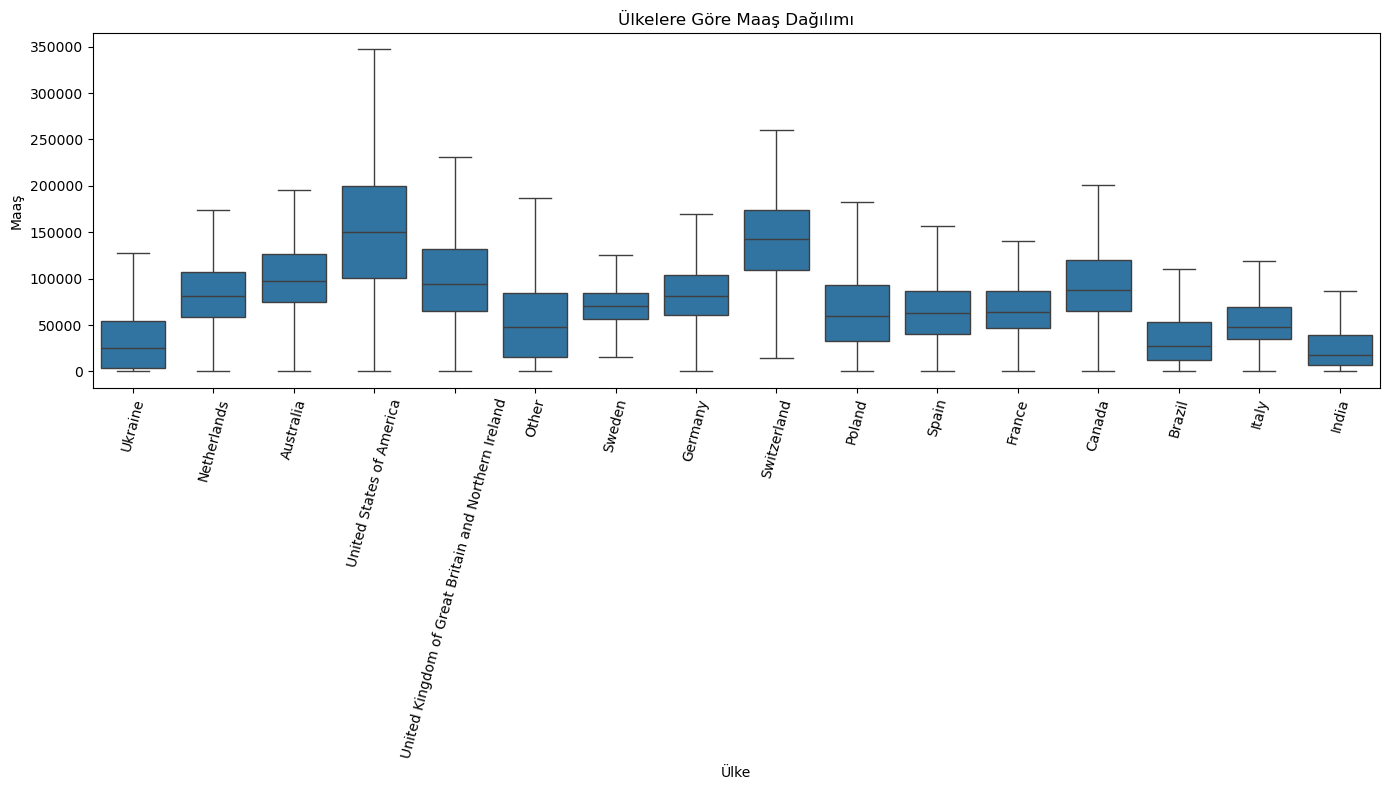

In [27]:
# Güvenli maaş kutu grafiği: ülke eşiği ve top-N sınırı ile
import seaborn as sns
import matplotlib.pyplot as plt

# Veri hazırlık
_df = df[['Country', 'Salary']].dropna().copy()
if _df.empty or 'Country' not in _df or 'Salary' not in _df:
    print('Uyarı: Görselleştirme için yeterli veri bulunamadı (Country/Salary boş).')
else:
    # Ülke başına minimum örnek sayısı eşiği
    MIN_PER_COUNTRY = 20
    counts = _df['Country'].value_counts()
    keep_countries = counts[counts >= MIN_PER_COUNTRY].index
    _df = _df[_df['Country'].isin(keep_countries)]

    # Eğer çok az kaldıysa eşiği gevşet
    if _df['Country'].nunique() == 0:
        MIN_PER_COUNTRY = 5
        keep_countries = counts[counts >= MIN_PER_COUNTRY].index
        _df = _df[_df['Country'].isin(keep_countries)]

    if _df['Country'].nunique() == 0:
        print('Uyarı: Ülke bazında yeterli örnek yok, grafiği çizemiyorum.')
    else:
        # En çok gözlemi olan ilk N ülkeyi alarak okunabilirliği artır
        TOP_COUNTRIES = 20
        top_countries = _df['Country'].value_counts().head(TOP_COUNTRIES).index
        _df = _df[_df['Country'].isin(top_countries)]

        plt.figure(figsize=(14, 8))
        sns.boxplot(data=_df, x='Country', y='Salary', showfliers=False)
        plt.title('Ülkelere Göre Maaş Dağılımı')
        plt.xlabel('Ülke')
        plt.ylabel('Maaş')
        plt.xticks(rotation=75)
        plt.tight_layout()
        plt.show()


In [28]:
# Üstteki küçük mavi çizgi aslında bizim kutumuz ve bunun üzerindekiler de aslında bizim aykırı değerlerimiz. Görüldüğü gibi çok fazla aykırı değer var
# Her bir ülke için tek tek max değeri hesaplayamayacağımız için genel grafiği incelediğimizde max maaşı 250 bin min maaş 10 bin dolar olarak tutacağız

df = df[df["Salary"] <= 250000]
df = df[df["Salary"] >= 10000]
df = df[df['Country'] != 'Other']

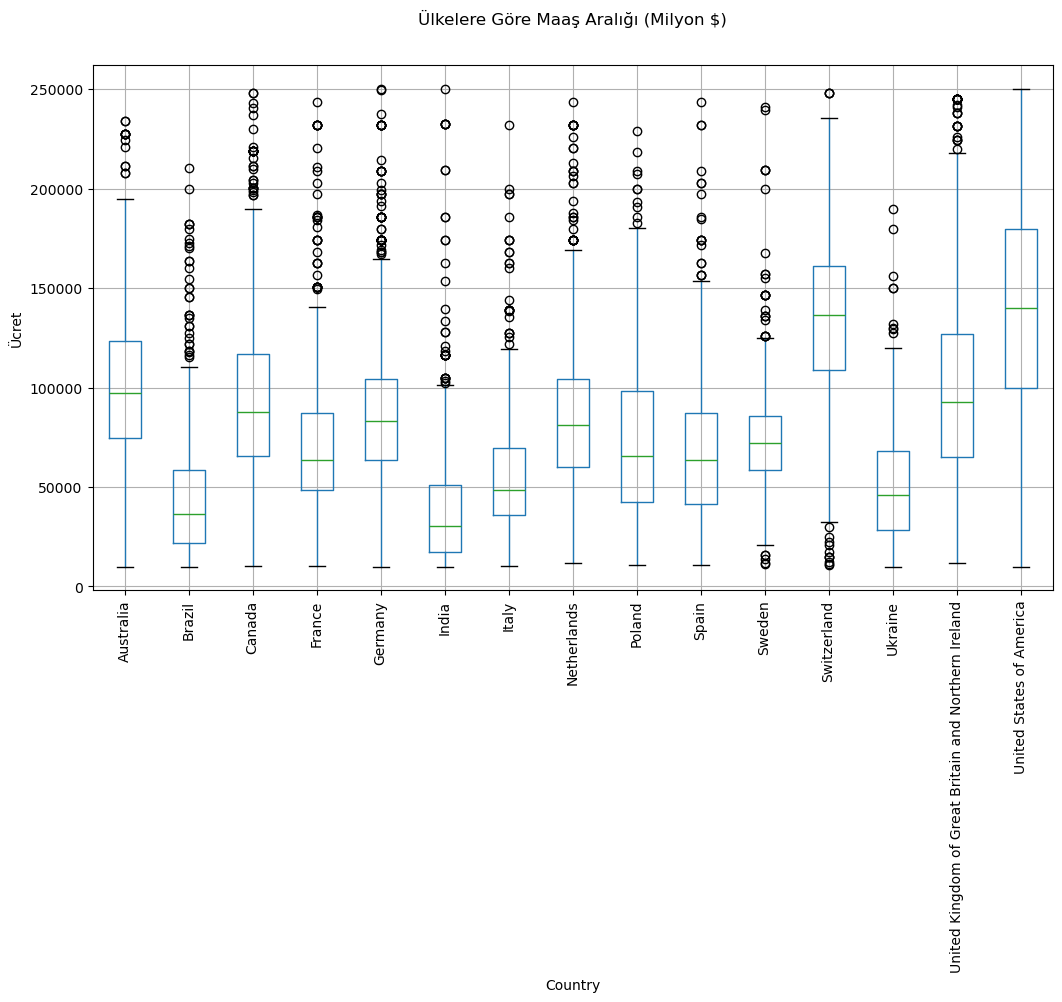

In [29]:
# Şimdi tekrar görselleştirelim

fig, ax = plt.subplots(1,1, figsize=(12, 7))
df.boxplot('Salary', 'Country', ax=ax)
plt.suptitle('Ülkelere Göre Maaş Aralığı (Milyon $)')
plt.title('')
plt.ylabel('Ücret')
plt.xticks(rotation=90)
plt.show()

# Veri Ön İşleme

In [30]:
df["YearsCodePro"].unique() # YearsCodePro sütunundaki benzersiz (tekrarsız) değerleri döndürür.

array([ 14.,  10.,  12.,   5.,  22.,  20.,  30.,  15.,   9.,  40.,  11.,
        41.,  36.,  23.,  26.,  25.,   8.,  38.,  35.,  21.,  19.,  18.,
        13.,  16.,  45.,  17.,  27.,   6.,   3.,  37.,   1.,  39.,  53.,
        28.,  33.,   7.,   2.,  24.,  29.,  50.,  48.,  44.,  31.,  42.,
        46.,  43.,  52.,  34.,  47.,  58.,   4.,  57.,  54.,  51.,  49.,
        32.,  55.,  56.,  60.,  59.,  63., 100.,  61.,  62.])

In [31]:
# Üsteki değerlerde 1'den az ve 50'den fazla gibi değerler olduğunda 1'den azsa 0.5'e, 50'den fazlaya 50'ye sabitlemek için ...
# ... "clean_experience" fonksiyonunu yazıyoruz

def clean_experience(x):
    if x ==  'More than 50 years':
        return 50
    if x == 'Less than 1 year':
        return 0.5
    return float(x)

df['YearsCodePro'] = df['YearsCodePro'].apply(clean_experience) # yeni YearsCodePro sütunumuz olarak ayarladık

In [32]:
# Aynısını "EdLevel" yani eğitim düzeyi için de düşünebiliriz

df["EdLevel"].unique()

array(['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Associate degree (A.A., A.S., etc.)',
       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
       'Some college/university study without earning a degree',
       'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'Primary/elementary school', 'Other (please specify):'],
      dtype=object)

In [33]:
# 'Professional degree' ya da 'Other doctoral' ise bunu 'Post grad' gibi düşünebiliriz
# Lisans Altı - Lisans - Yüksek Lisans - Doktora gibi derecelendirdik

def clean_education(x):
    if 'Bachelor’s degree' in x:
        return 'Bachelor’s degree'
    if 'Master’s degree' in x:
        return 'Master’s degree'
    if 'Professional degree' in x or 'Other doctoral' in x:
        return 'Post grad'
    return 'Less than a Bachelors'

df['EdLevel'] = df['EdLevel'].apply(clean_education) # yeni EdLevel sütunumuz olarak ayarladık

In [34]:
df["EdLevel"].unique() # kontrol edelim

array(['Master’s degree', 'Less than a Bachelors', 'Bachelor’s degree',
       'Post grad'], dtype=object)

 - LabelEncoder Dönüşümü

Kategorik verilerimizi sayısal verilere dönüştürmek için LabelEncoder kullanacağız. LabelEncoder, örneğin kadın 0 , erkek 1 ile temsil edilmesini sağlıyor.

In [35]:
# EdLevel değişkenimizee LabelEncoder uyguladık

from sklearn.preprocessing import LabelEncoder

le_education = LabelEncoder()
df['EdLevel'] = le_education.fit_transform(df['EdLevel'])
df["EdLevel"].unique()

array([2, 1, 0, 3])

In [36]:
# Country değişkenimizee LabelEncoder uyguladık

le_country = LabelEncoder()
df['Country'] = le_country.fit_transform(df['Country'])
df["Country"].unique()

array([12,  7,  0, 14, 13, 10,  4, 11,  8,  9,  3,  2,  1,  6,  5])

In [50]:
# Country değişkenimizee LabelEncoder uyguladık


from sklearn.preprocessing import LabelEncoder


le_employment = LabelEncoder()
df['Employment'] = df['Employment'].fillna('Unknown')
df['Employment'] = le_employment.fit_transform(df['Employment'])
df["Country"].unique()


array([12,  7,  0, 14, 13, 10,  4, 11,  8,  9,  3,  2,  1,  6,  5])

# Modelleme

In [51]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [52]:
X.head()

,Country,EdLevel,YearsCodePro,Employment,Employment_LE
0,12,2,14.0,0,0
1,7,1,10.0,0,0
2,12,0,12.0,2,2
3,12,0,5.0,0,0
4,12,2,22.0,2,2


In [53]:
y.head()

0     61256.0
1    104413.0
2     53061.0
3     36197.0
4     60000.0
Name: Salary, dtype: float64

- **1.Model: Liner Regresyon**

In [54]:
# MODEL

from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X, y.values)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
# TAHMİN
y_pred = linear_reg.predict(X)

In [ ]:
# HATA ORANI

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

error = np.sqrt(mean_squared_error(y, y_pred)) # normalde y_test vs şeklinde ayırmamız gerekiyordu x ve y'yi ancak burada basit olması açısından bunu tüm veriler üzerinden yapıyoruz
print("${:,.02f}".format(error))

# Bu şu anlama geliyor: Ücretlerin 10.000 - 250.000 aralığında olduğunu düşünürsek maaşı her tahmin ettiğimizde ortalama olarak $ 47.341 dolar sapmış oluyoruz.

$47,341.49


- **2.Model: Karar Ağaçları**

In [57]:
# MODEL

from sklearn.tree import DecisionTreeRegressor
dec_tree_reg = DecisionTreeRegressor(random_state=42)
dec_tree_reg.fit(X, y.values)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [58]:
# TAHMİN

y_pred = dec_tree_reg.predict(X)

In [ ]:
# HATA ORANI

error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

# Bu şu anlama geliyor: Ücretlerin 10.000 - 250.000 aralığında olduğunu düşünürsek maaşı her tahmin ettiğimizde ortalama olarak $ 34,582 dolar sapmış oluyoruz.

$34,582.20


- **3.Model: Random Forest**

In [60]:
# MODEL

from sklearn.ensemble import RandomForestRegressor

random_forest_reg = RandomForestRegressor(random_state=42)
random_forest_reg.fit(X, y.values)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
# TAHMİN

y_pred = random_forest_reg.predict(X)

In [ ]:
# HATA ORANI

error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

# Bu şu anlama geliyor: Ücretlerin 10.000 - 250.000 aralığında olduğunu düşünürsek maaşı her tahmin ettiğimizde ortalama olarak $ 35,086 dolar sapmış oluyoruz.

$35,086.10


- **4.Model: GBM**

In [63]:
# MODEL

from sklearn.ensemble import GradientBoostingRegressor

gbm_model = GradientBoostingRegressor(random_state=42)
gbm_model.fit(X, y.values)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [64]:
# TAHMİN

y_pred = gbm_model.predict(X)

In [ ]:
# HATA ORANI

error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

# Bu şu anlama geliyor: Ücretlerin 10.000 - 250.000 aralığında olduğunu düşünürsek maaşı her tahmin ettiğimizde ortalama olarak $ 39,666 dolar sapmış oluyoruz.

$39,666.35


**Modellerin Karşılaştırılması**

In [66]:
# MODELLER

modeller = [linear_reg , dec_tree_reg , random_forest_reg , gbm_model]

sonuc = []

sonuclar = pd.DataFrame(columns=["Modeller" , "Accuracy"])

In [67]:
for model in modeller:
    isimler = model.__class__.__name__
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    # Doğruluk oranını % olarak hesapla (1 - RMSE/ortalama_maaş)
    doğruluk = (1 - rmse / y.mean()) * 100
    sonuc = pd.DataFrame([[isimler, doğruluk]], columns=["Modeller", "Accuracy"])
    sonuclar = pd.concat([sonuclar, sonuc], ignore_index=True)

C:\Users\BedirhanOrseloglu\AppData\Local\Temp\ipykernel_6344\3343963280.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sonuclar = pd.concat([sonuclar, sonuc], ignore_index=True)


In [68]:
sonuclar

# Denediğimiz modeller arasında en iyi sonucu Karar Ağaçları verdi

,Modeller,Accuracy
0,LinearRegression,51.841873
1,DecisionTreeRegressor,64.821265
2,RandomForestRegressor,64.308666
3,GradientBoostingRegressor,59.649408


# Modellerin R2, MAPE, MAE ve MSE Değerleri

In [69]:
# Modeller için r2, MAPE, MAE ve MSE hesaplama
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

models = [linear_reg, dec_tree_reg, random_forest_reg, gbm_model]
model_names = [m.__class__.__name__ for m in models]

metrics_rows = []
for model, name in zip(models, model_names):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mape = mean_absolute_percentage_error(y, y_pred) * 100  # yüzde
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    metrics_rows.append({
        'Model': name,
        'R2': r2,
        'MAPE_%': mape,
        'MAE': mae,
        'MSE': mse,
    })

metrics_df = pd.DataFrame(metrics_rows)
# Görsellik için R2 azalan sıralama
metrics_df.sort_values('R2', ascending=False).reset_index(drop=True)


# R2 (R-squared): Modelin varyansın ne kadarını açıkladığını gösterir, 1'e yakın olması daha iyi performans anlamına gelir
# MAPE (Mean Absolute Percentage Error): Ortalama mutlak yüzde hata, düşük değerler daha iyi tahmin performansını gösterir
# MAE (Mean Absolute Error): Ortalama mutlak hata, gerçek ve tahmin edilen değerler arasındaki ortalama farkı gösterir, düşük değerler tercih edilir
# MSE (Mean Squared Error): Ortalama kare hata, büyük hataları daha fazla cezalandırır, düşük değerler daha iyi model performansını işaret eder



,Model,R2,MAPE_%,MAE,MSE
0,DecisionTreeRegressor,0.610423,33.463234,24426.885528,1.195928e+09
1,RandomForestRegressor,0.598987,36.182565,25741.657820,1.231035e+09
2,GradientBoostingRegressor,0.487455,45.037154,29756.561427,1.573419e+09
3,LinearRegression,0.269918,62.780465,37415.762489,2.241217e+09


# Kümeleme ve Elbow ile Optimum k

In [75]:
# K-Means Kümeleme Analizi
# Amaç: Geliştiricileri gruplandırarak önemli kodlama dilleri, 
# kod öğrenme kaynakları ve sektör talepleri hakkında bilgi edinmek

# Veri setini yeniden yükleyelim (tüm sütunlarla)
df_cluster = pd.read_csv("survey_results_public.csv")

# İlgili sütunları seçelim
clustering_columns = [
    'LanguageHaveWorkedWith',  # Kullanılan diller
    'LanguageWantToWorkWith',  # İstenen diller
    'LearnCode',               # Kod öğrenme kaynakları
    'DevType',                 # Geliştirici tipi
    'Country',                 # Ülke
    'YearsCode'                # Deneyim
]

df_cluster = df_cluster[clustering_columns].copy()

# Boş değerleri çıkaralım
df_cluster = df_cluster.dropna()

print(f"Kümeleme için kullanılacak veri boyutu: {df_cluster.shape}")
df_cluster.head()


Kümeleme için kullanılacak veri boyutu: (19955, 6)


,LanguageHaveWorkedWith,LanguageWantToWorkWith,LearnCode,DevType,Country,YearsCode
0,Bash/Shell (all shells);Dart;SQL,Dart,Online Courses or Certification (includes all ...,"Developer, mobile",Ukraine,14.0
1,Java,Java;Python;Swift,Online Courses or Certification (includes all ...,"Developer, back-end",Netherlands,10.0
2,Dart;HTML/CSS;JavaScript;TypeScript,Dart;HTML/CSS;JavaScript;TypeScript,Online Courses or Certification (includes all ...,"Developer, front-end",Ukraine,12.0
3,Java;Kotlin;SQL,Java;Kotlin,"Other online resources (e.g. standard search, ...","Developer, back-end",Ukraine,5.0
5,Java;Scala,Java;Kotlin;Scala,Online Courses or Certification (includes all ...,"Developer, back-end",Ukraine,20.0


In [76]:
# Veri Ön İşleme - Multi-Label sütunları için One-Hot Encoding

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder

# Noktalı virgülle ayrılmış değerleri liste haline getiren fonksiyon
def split_multi_value(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(';')]

# Multi-label sütunlar için binarizer
mlb_languages_have = MultiLabelBinarizer()
mlb_languages_want = MultiLabelBinarizer()
mlb_learn_code = MultiLabelBinarizer()
mlb_dev_type = MultiLabelBinarizer()

# Dilleri listeye çevirelim
languages_have = df_cluster['LanguageHaveWorkedWith'].apply(split_multi_value)
languages_want = df_cluster['LanguageWantToWorkWith'].apply(split_multi_value)
learn_sources = df_cluster['LearnCode'].apply(split_multi_value)
dev_types = df_cluster['DevType'].apply(split_multi_value)

# One-hot encoding uygulayalım
languages_have_encoded = mlb_languages_have.fit_transform(languages_have)
languages_want_encoded = mlb_languages_want.fit_transform(languages_want)
learn_sources_encoded = mlb_learn_code.fit_transform(learn_sources)
dev_types_encoded = mlb_dev_type.fit_transform(dev_types)

# DataFrame'lere çevirelim
df_lang_have = pd.DataFrame(languages_have_encoded, 
                            columns=['Lang_Have_' + col for col in mlb_languages_have.classes_],
                            index=df_cluster.index)

df_lang_want = pd.DataFrame(languages_want_encoded,
                            columns=['Lang_Want_' + col for col in mlb_languages_want.classes_],
                            index=df_cluster.index)

df_learn = pd.DataFrame(learn_sources_encoded,
                        columns=['Learn_' + col for col in mlb_learn_code.classes_],
                        index=df_cluster.index)

df_dev = pd.DataFrame(dev_types_encoded,
                      columns=['DevType_' + col for col in mlb_dev_type.classes_],
                      index=df_cluster.index)

print(f"Kullanılan dil sayısı: {len(mlb_languages_have.classes_)}")
print(f"İstenen dil sayısı: {len(mlb_languages_want.classes_)}")
print(f"Öğrenme kaynağı sayısı: {len(mlb_learn_code.classes_)}")
print(f"Geliştirici tipi sayısı: {len(mlb_dev_type.classes_)}")


Kullanılan dil sayısı: 42
İstenen dil sayısı: 42
Öğrenme kaynağı sayısı: 13
Geliştirici tipi sayısı: 32


In [77]:
# Country ve YearsCode için encoding

le_country_cluster = LabelEncoder()
df_cluster['Country_Encoded'] = le_country_cluster.fit_transform(df_cluster['Country'])

# YearsCode'u sayısal hale getirelim (bazen "Less than 1 year", "More than 50 years" gibi değerler olabilir)
def convert_years(value):
    if pd.isna(value):
        return 0
    value_str = str(value).lower()
    if 'less' in value_str:
        return 0.5
    elif 'more' in value_str:
        return 50
    else:
        try:
            return float(value)
        except:
            return 0

df_cluster['YearsCode_Numeric'] = df_cluster['YearsCode'].apply(convert_years)

print("Ülke ve deneyim encoding tamamlandı!")


Ülke ve deneyim encoding tamamlandı!


In [78]:
# Tüm özellikleri birleştirelim

# Numerik sütunları alalım
numeric_features = df_cluster[['Country_Encoded', 'YearsCode_Numeric']].reset_index(drop=True)

# Tüm DataFrame'leri birleştirelim
X_cluster = pd.concat([
    numeric_features,
    df_lang_have.reset_index(drop=True),
    df_lang_want.reset_index(drop=True),
    df_learn.reset_index(drop=True),
    df_dev.reset_index(drop=True)
], axis=1)

print(f"Kümeleme için hazırlanan veri seti boyutu: {X_cluster.shape}")
print(f"Toplam özellik sayısı: {X_cluster.shape[1]}")

# Standartlaştırma (K-means için önemli)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("\nStandartlaştırma tamamlandı!")
print(f"Ölçeklendirilmiş veri boyutu: {X_cluster_scaled.shape}")


Kümeleme için hazırlanan veri seti boyutu: (19955, 131)
Toplam özellik sayısı: 131

Standartlaştırma tamamlandı!
Ölçeklendirilmiş veri boyutu: (19955, 131)


In [79]:
# ELBOW YÖNTEMİ İLE OPTİMAL K SAYISINI BULMA

from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Veri seti çok büyükse, örnekleme yapalım (hesaplama süresini azaltmak için)
sample_size = min(5000, len(X_cluster_scaled))
np.random.seed(42)
sample_indices = np.random.choice(len(X_cluster_scaled), sample_size, replace=False)
X_sample = X_cluster_scaled[sample_indices]

print(f"Elbow analizi için kullanılan örnek boyutu: {X_sample.shape}")

# Farklı k değerleri için WCSS (Within-Cluster Sum of Squares) hesaplayalım
wcss = []
k_range = range(2, 11)  # 2'den 10'a kadar k değerlerini deneyelim

print("\nK-Means modelleri eğitiliyor...")
for k in k_range:
    print(f"K = {k} için model eğitiliyor...", end=' ')
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_sample)
    wcss.append(kmeans.inertia_)
    print(f"WCSS: {kmeans.inertia_:.2f}")

print("\nWCSS hesaplama tamamlandı!")


Elbow analizi için kullanılan örnek boyutu: (5000, 131)

K-Means modelleri eğitiliyor...
K = 2 için model eğitiliyor... WCSS: 621316.50
K = 3 için model eğitiliyor... WCSS: 604047.62
K = 4 için model eğitiliyor... WCSS: 592657.27
K = 5 için model eğitiliyor... WCSS: 585460.81
K = 6 için model eğitiliyor... WCSS: 579453.29
K = 7 için model eğitiliyor... WCSS: 575053.16
K = 8 için model eğitiliyor... WCSS: 567285.17
K = 9 için model eğitiliyor... WCSS: 563000.18
K = 10 için model eğitiliyor... WCSS: 556911.49

WCSS hesaplama tamamlandı!


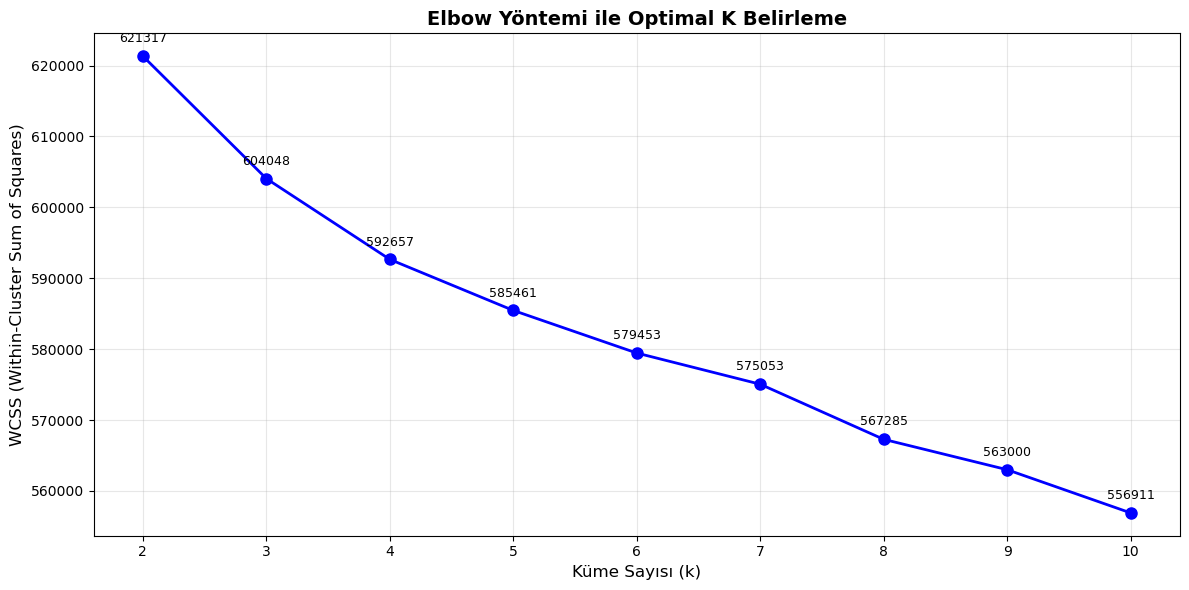


ELBOW GRAFİĞİ ANALİZİ

Grafikteki 'dirsek' noktası optimal küme sayısını gösterir.
Dirsek noktası, WCSS'nin hızlı düşüşünün yavaşladığı yerdir.

WCSS değerleri:
K = 2: WCSS = 621316.50
K = 3: WCSS = 604047.62
K = 4: WCSS = 592657.27
K = 5: WCSS = 585460.81
K = 6: WCSS = 579453.29
K = 7: WCSS = 575053.16
K = 8: WCSS = 567285.17
K = 9: WCSS = 563000.18
K = 10: WCSS = 556911.49


In [80]:
# ELBOW GRAFİĞİNİ ÇİZELİM

plt.figure(figsize=(12, 6))

# Elbow grafiği
plt.plot(k_range, wcss, marker='o', linestyle='-', linewidth=2, markersize=8, color='blue')
plt.xlabel('Küme Sayısı (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Yöntemi ile Optimal K Belirleme', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Her noktanın WCSS değerini gösterelim
for i, (k, w) in enumerate(zip(k_range, wcss)):
    plt.annotate(f'{w:.0f}', xy=(k, w), xytext=(0, 10), 
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ELBOW GRAFİĞİ ANALİZİ")
print("="*60)
print("\nGrafikteki 'dirsek' noktası optimal küme sayısını gösterir.")
print("Dirsek noktası, WCSS'nin hızlı düşüşünün yavaşladığı yerdir.")
print("\nWCSS değerleri:")
for k, w in zip(k_range, wcss):
    print(f"K = {k}: WCSS = {w:.2f}")


In [81]:
# SİLHOUETTE SKORU İLE OPTİMAL K'YI DOĞRULAMA

from sklearn.metrics import silhouette_score

silhouette_scores = []

print("Silhouette skorları hesaplanıyor...")
for k in k_range:
    print(f"K = {k} için hesaplanıyor...", end=' ')
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score: {score:.4f}")

# En yüksek Silhouette skoruna sahip k'yi bulalım
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"\nEn yüksek Silhouette skoruna sahip k: {optimal_k_silhouette}")
print(f"Silhouette skoru: {max(silhouette_scores):.4f}")


Silhouette skorları hesaplanıyor...
K = 2 için hesaplanıyor... Silhouette Score: 0.1250
K = 3 için hesaplanıyor... Silhouette Score: 0.0349
K = 4 için hesaplanıyor... Silhouette Score: 0.0074
K = 5 için hesaplanıyor... Silhouette Score: 0.0061
K = 6 için hesaplanıyor... Silhouette Score: -0.0006
K = 7 için hesaplanıyor... Silhouette Score: 0.0193
K = 8 için hesaplanıyor... Silhouette Score: 0.0077
K = 9 için hesaplanıyor... Silhouette Score: -0.0102
K = 10 için hesaplanıyor... Silhouette Score: 0.0093

En yüksek Silhouette skoruna sahip k: 2
Silhouette skoru: 0.1250


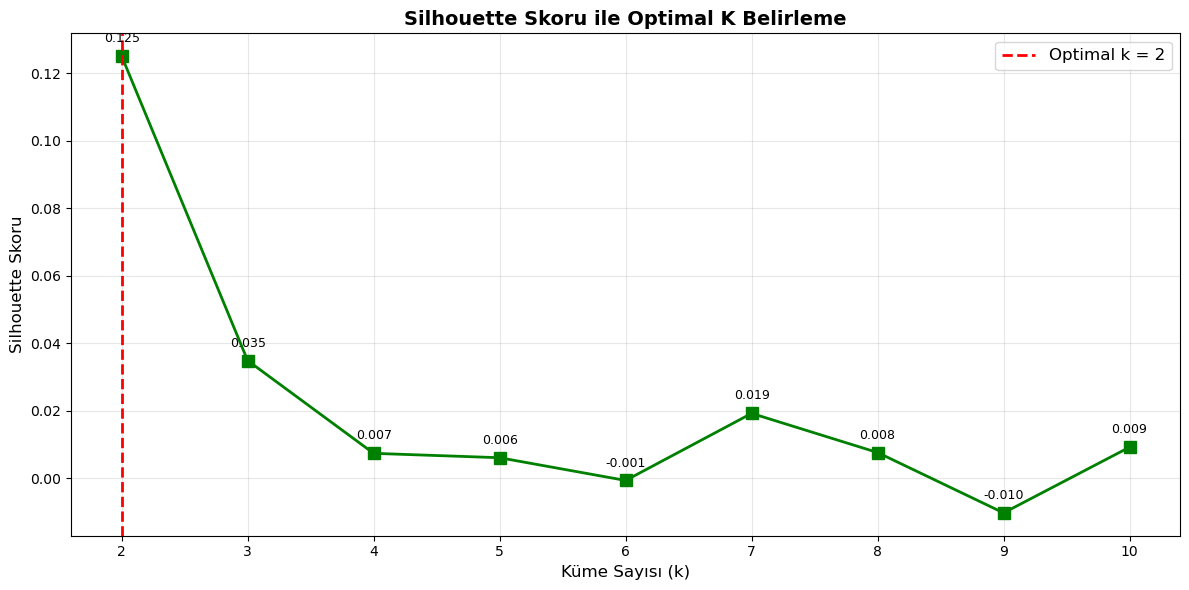


SİLHOUETTE SKORU ANALİZİ

Silhouette skoru -1 ile 1 arasında değer alır.
1'e yakın değerler, kümelerin iyi ayrıldığını gösterir.

Silhouette skorları:
K = 2: Silhouette Score = 0.1250
K = 3: Silhouette Score = 0.0349
K = 4: Silhouette Score = 0.0074
K = 5: Silhouette Score = 0.0061
K = 6: Silhouette Score = -0.0006
K = 7: Silhouette Score = 0.0193
K = 8: Silhouette Score = 0.0077
K = 9: Silhouette Score = -0.0102
K = 10: Silhouette Score = 0.0093


In [82]:
# SİLHOUETTE SKORU GRAFİĞİ

plt.figure(figsize=(12, 6))

plt.plot(k_range, silhouette_scores, marker='s', linestyle='-', linewidth=2, markersize=8, color='green')
plt.xlabel('Küme Sayısı (k)', fontsize=12)
plt.ylabel('Silhouette Skoru', fontsize=12)
plt.title('Silhouette Skoru ile Optimal K Belirleme', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# En yüksek skoru işaretleyelim
max_idx = np.argmax(silhouette_scores)
plt.axvline(x=k_range[max_idx], color='red', linestyle='--', linewidth=2, label=f'Optimal k = {k_range[max_idx]}')
plt.legend(fontsize=12)

# Her noktanın skorunu gösterelim
for k, score in zip(k_range, silhouette_scores):
    plt.annotate(f'{score:.3f}', xy=(k, score), xytext=(0, 10), 
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SİLHOUETTE SKORU ANALİZİ")
print("="*60)
print("\nSilhouette skoru -1 ile 1 arasında değer alır.")
print("1'e yakın değerler, kümelerin iyi ayrıldığını gösterir.")
print("\nSilhouette skorları:")
for k, score in zip(k_range, silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")


In [83]:
# ELBOW YÖNTEMİ İLE OTOMATİK OPTİMAL K BELİRLEME
# (İkinci türev yöntemi - en büyük eğrilik noktası)

# WCSS değerlerini normalize edelim
wcss_normalized = np.array(wcss)
wcss_normalized = (wcss_normalized - wcss_normalized.min()) / (wcss_normalized.max() - wcss_normalized.min())

# İkinci türevi hesaplayalım
second_derivative = np.diff(wcss_normalized, n=2)

# En büyük ikinci türev değerine sahip k'yi bulalım (dirsek noktası)
elbow_idx = np.argmax(np.abs(second_derivative)) + 2  # +2 çünkü 2 kez türev aldık
optimal_k_elbow = k_range[elbow_idx]

print("="*60)
print("OTOMATİK OPTİMAL K BELİRLEME SONUÇLARI")
print("="*60)
print(f"\nElbow Yöntemi (otomatik): k = {optimal_k_elbow}")
print(f"Silhouette Skoru Yöntemi: k = {optimal_k_silhouette}")
print("\n" + "="*60)
print("SONUÇ VE ÖNERİ")
print("="*60)

# Her iki yöntemi de değerlendirelim
if optimal_k_elbow == optimal_k_silhouette:
    recommended_k = optimal_k_elbow
    print(f"\n✓ Her iki yöntem de aynı sonucu verdi!")
    print(f"  ÖNERİLEN KÜME SAYISI: k = {recommended_k}")
else:
    print(f"\n⚠ İki yöntem farklı sonuçlar verdi:")
    print(f"  - Elbow Yöntemi: k = {optimal_k_elbow}")
    print(f"  - Silhouette Yöntemi: k = {optimal_k_silhouette}")
    print(f"\n  İki değer arasında bir k seçebilirsiniz.")
    recommended_k = optimal_k_silhouette  # Silhouette genellikle daha güvenilir
    print(f"  ÖNERİLEN: k = {recommended_k} (Silhouette skoruna göre)")

print("\n" + "="*60)


OTOMATİK OPTİMAL K BELİRLEME SONUÇLARI

Elbow Yöntemi (otomatik): k = 4
Silhouette Skoru Yöntemi: k = 2

SONUÇ VE ÖNERİ

⚠ İki yöntem farklı sonuçlar verdi:
  - Elbow Yöntemi: k = 4
  - Silhouette Yöntemi: k = 2

  İki değer arasında bir k seçebilirsiniz.
  ÖNERİLEN: k = 2 (Silhouette skoruna göre)



In [84]:
# OPTİMAL K İLE K-MEANS MODELİNİ EĞİTELİM

print(f"Optimal k = {recommended_k} ile K-Means modeli eğitiliyor...")

# Tüm veri seti üzerinde eğitelim (sadece örnek değil)
final_kmeans = KMeans(n_clusters=recommended_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

print(f"✓ Model başarıyla eğitildi!")
print(f"\nKüme dağılımı:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Küme {cluster_id}: {count} kişi (%{percentage:.1f})")

# Küme etiketlerini orijinal DataFrame'e ekleyelim
df_cluster['Cluster'] = cluster_labels

print(f"\n✓ Küme etiketleri DataFrame'e eklendi!")


Optimal k = 2 ile K-Means modeli eğitiliyor...
✓ Model başarıyla eğitildi!

Küme dağılımı:
  Küme 0: 17121 kişi (%85.8)
  Küme 1: 2834 kişi (%14.2)

✓ Küme etiketleri DataFrame'e eklendi!


In [85]:
# KÜME ANALİZİ - HER KÜME İÇİN ÖZELLİKLER

print("="*80)
print("KÜME ANALİZİ - HER KÜME İÇİN ÖNEMLİ BİLGİLER")
print("="*80)

def analyze_cluster(cluster_id):
    """Bir küme için detaylı analiz yapar"""
    cluster_data = df_cluster[df_cluster['Cluster'] == cluster_id]
    
    print(f"\n{'='*80}")
    print(f"KÜME {cluster_id} ANALİZİ")
    print(f"{'='*80}")
    print(f"Toplam Kişi Sayısı: {len(cluster_data)}")
    print(f"Yüzde: %{(len(cluster_data) / len(df_cluster)) * 100:.1f}")
    
    # Ortalama deneyim
    avg_experience = cluster_data['YearsCode_Numeric'].mean()
    print(f"\nOrtalama Deneyim: {avg_experience:.1f} yıl")
    
    # En popüler ülkeler
    print(f"\n📍 En Popüler Ülkeler (Top 5):")
    top_countries = cluster_data['Country'].value_counts().head(5)
    for country, count in top_countries.items():
        print(f"   • {country}: {count} kişi")
    
    # En çok kullanılan diller
    print(f"\n💻 En Çok Kullanılan Programlama Dilleri (Top 10):")
    all_langs_have = []
    for langs in cluster_data['LanguageHaveWorkedWith'].dropna():
        all_langs_have.extend([l.strip() for l in str(langs).split(';')])
    
    if all_langs_have:
        lang_counts = pd.Series(all_langs_have).value_counts().head(10)
        for lang, count in lang_counts.items():
            percentage = (count / len(cluster_data)) * 100
            print(f"   • {lang}: {count} kişi (%{percentage:.1f})")
    
    # En çok istenen diller
    print(f"\n🎯 En Çok Çalışmak İstenen Diller (Top 10):")
    all_langs_want = []
    for langs in cluster_data['LanguageWantToWorkWith'].dropna():
        all_langs_want.extend([l.strip() for l in str(langs).split(';')])
    
    if all_langs_want:
        lang_want_counts = pd.Series(all_langs_want).value_counts().head(10)
        for lang, count in lang_want_counts.items():
            percentage = (count / len(cluster_data)) * 100
            print(f"   • {lang}: {count} kişi (%{percentage:.1f})")
    
    # En popüler öğrenme kaynakları
    print(f"\n📚 Kod Öğrenme Kaynakları (Top 10):")
    all_learn = []
    for sources in cluster_data['LearnCode'].dropna():
        all_learn.extend([s.strip() for s in str(sources).split(';')])
    
    if all_learn:
        learn_counts = pd.Series(all_learn).value_counts().head(10)
        for source, count in learn_counts.items():
            percentage = (count / len(cluster_data)) * 100
            print(f"   • {source}: {count} kişi (%{percentage:.1f})")
    
    # Geliştirici tipleri
    print(f"\n👨‍💻 Geliştirici Tipleri (Top 10):")
    all_devtypes = []
    for devtypes in cluster_data['DevType'].dropna():
        all_devtypes.extend([d.strip() for d in str(devtypes).split(';')])
    
    if all_devtypes:
        devtype_counts = pd.Series(all_devtypes).value_counts().head(10)
        for devtype, count in devtype_counts.items():
            percentage = (count / len(cluster_data)) * 100
            print(f"   • {devtype}: {count} kişi (%{percentage:.1f})")

# Her küme için analiz yapalım
for cluster_id in range(recommended_k):
    analyze_cluster(cluster_id)

print(f"\n{'='*80}")
print("KÜME ANALİZİ TAMAMLANDI")
print(f"{'='*80}")


KÜME ANALİZİ - HER KÜME İÇİN ÖNEMLİ BİLGİLER

KÜME 0 ANALİZİ
Toplam Kişi Sayısı: 17121
Yüzde: %85.8

Ortalama Deneyim: 16.4 yıl

📍 En Popüler Ülkeler (Top 5):
   • United States of America: 3406 kişi
   • Germany: 1463 kişi
   • India: 1243 kişi
   • United Kingdom of Great Britain and Northern Ireland: 912 kişi
   • France: 656 kişi

💻 En Çok Kullanılan Programlama Dilleri (Top 10):
   • JavaScript: 11672 kişi (%68.2)
   • HTML/CSS: 10939 kişi (%63.9)
   • SQL: 10380 kişi (%60.6)
   • Python: 10081 kişi (%58.9)
   • Bash/Shell (all shells): 8053 kişi (%47.0)
   • TypeScript: 8007 kişi (%46.8)
   • Java: 4962 kişi (%29.0)
   • C#: 4758 kişi (%27.8)
   • PowerShell: 3937 kişi (%23.0)
   • C++: 3324 kişi (%19.4)

🎯 En Çok Çalışmak İstenen Diller (Top 10):
   • Python: 8016 kişi (%46.8)
   • SQL: 7350 kişi (%42.9)
   • JavaScript: 7081 kişi (%41.4)
   • HTML/CSS: 6918 kişi (%40.4)
   • TypeScript: 6840 kişi (%40.0)
   • Rust: 5557 kişi (%32.5)
   • Bash/Shell (all shells): 5069 kişi (%29.

Kümeler PCA ile 2D'ye indirgeniyor...
Açıklanan varyans: %9.59
  - PC1: %6.25
  - PC2: %3.35


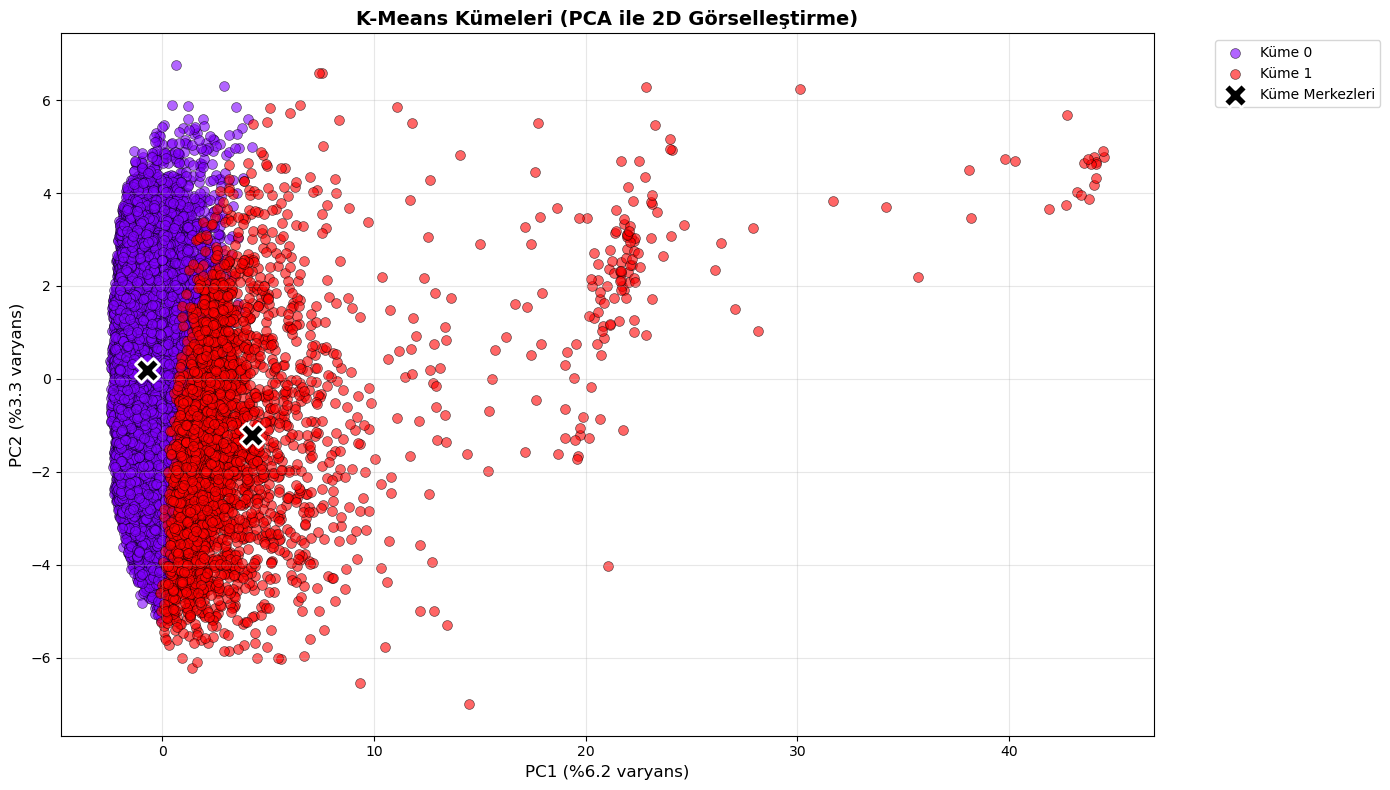


✓ Görselleştirme tamamlandı!


In [86]:
# KÜMELERİN GÖRSELLEŞTİRİLMESİ (PCA İLE 2D İNDİRGEME)

from sklearn.decomposition import PCA

print("Kümeler PCA ile 2D'ye indirgeniyor...")

# PCA ile 2 boyuta indirgeyelim
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"Açıklanan varyans: %{sum(pca.explained_variance_ratio_) * 100:.2f}")
print(f"  - PC1: %{pca.explained_variance_ratio_[0] * 100:.2f}")
print(f"  - PC2: %{pca.explained_variance_ratio_[1] * 100:.2f}")

# Görselleştirme
plt.figure(figsize=(14, 8))

# Her küme için farklı renk
colors = plt.cm.rainbow(np.linspace(0, 1, recommended_k))

for cluster_id in range(recommended_k):
    cluster_points = X_pca[cluster_labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=[colors[cluster_id]], label=f'Küme {cluster_id}',
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Küme merkezlerini gösterelim
centers_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='black', marker='X', s=300, edgecolors='white', linewidth=2,
           label='Küme Merkezleri', zorder=5)

plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0] * 100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1] * 100:.1f} varyans)', fontsize=12)
plt.title('K-Means Kümeleri (PCA ile 2D Görselleştirme)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Görselleştirme tamamlandı!")


In [87]:
# KÜMELERİN KARŞILAŞTIRMALI ÖZET TABLOSU

print("="*80)
print("KÜMELEME ANALİZİ ÖZET RAPORU")
print("="*80)

summary_data = []

for cluster_id in range(recommended_k):
    cluster_data = df_cluster[df_cluster['Cluster'] == cluster_id]
    
    # En popüler 3 dil
    all_langs = []
    for langs in cluster_data['LanguageHaveWorkedWith'].dropna():
        all_langs.extend([l.strip() for l in str(langs).split(';')])
    top_3_langs = ', '.join(pd.Series(all_langs).value_counts().head(3).index.tolist()) if all_langs else 'N/A'
    
    # En popüler 3 öğrenme kaynağı
    all_learn = []
    for sources in cluster_data['LearnCode'].dropna():
        all_learn.extend([s.strip() for s in str(sources).split(';')])
    top_3_learn = ', '.join(pd.Series(all_learn).value_counts().head(3).index.tolist()) if all_learn else 'N/A'
    
    # En popüler 2 geliştirici tipi
    all_devtypes = []
    for devtypes in cluster_data['DevType'].dropna():
        all_devtypes.extend([d.strip() for d in str(devtypes).split(';')])
    top_2_devtype = ', '.join(pd.Series(all_devtypes).value_counts().head(2).index.tolist()) if all_devtypes else 'N/A'
    
    # En popüler ülke
    top_country = cluster_data['Country'].value_counts().index[0] if len(cluster_data) > 0 else 'N/A'
    
    summary_data.append({
        'Küme': cluster_id,
        'Kişi Sayısı': len(cluster_data),
        'Yüzde (%)': f"{(len(cluster_data) / len(df_cluster)) * 100:.1f}",
        'Ort. Deneyim (yıl)': f"{cluster_data['YearsCode_Numeric'].mean():.1f}",
        'En Popüler Ülke': top_country,
        'Top 3 Dil': top_3_langs,
        'Top 3 Öğrenme Kaynağı': top_3_learn,
        'Top 2 Geliştirici Tipi': top_2_devtype
    })

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("NOT: Bu tablo her kümenin genel profilini özetlemektedir.")
print("="*80)


KÜMELEME ANALİZİ ÖZET RAPORU


 Küme  Kişi Sayısı Yüzde (%) Ort. Deneyim (yıl)          En Popüler Ülke                          Top 3 Dil                                                                                                                                                      Top 3 Öğrenme Kaynağı                     Top 2 Geliştirici Tipi
    0        17121      85.8               16.4 United States of America          JavaScript, HTML/CSS, SQL Technical documentation (is generated for/by the tool or system), Other online resources (e.g. standard search, forum, online community), Stack Overflow or Stack Exchange Developer, full-stack, Developer, back-end
    1         2834      14.2               14.4 United States of America Python, Bash/Shell (all shells), C Technical documentation (is generated for/by the tool or system), Other online resources (e.g. standard search, forum, online community), Stack Overflow or Stack Exchange             Student, Developer, full-stack

NO

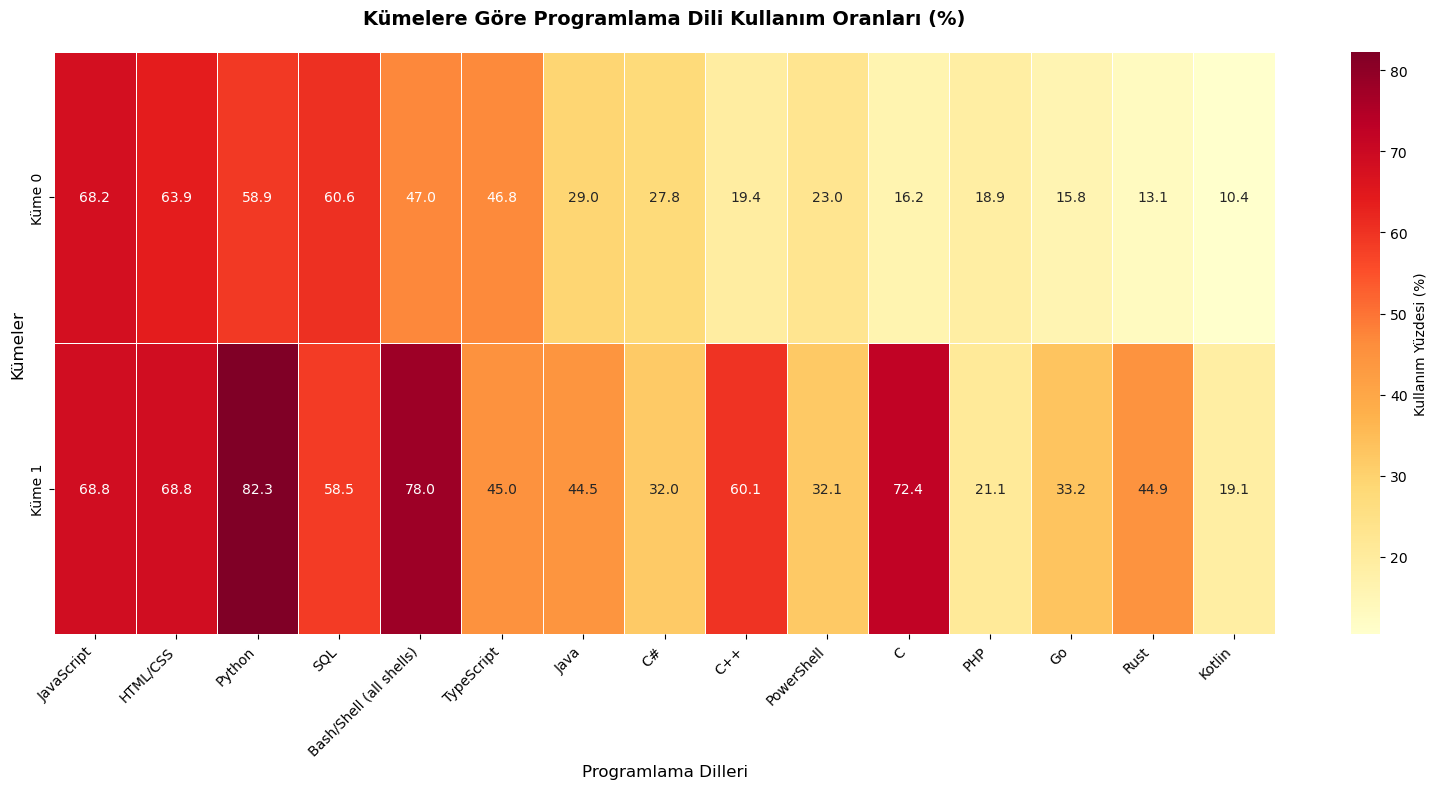


✓ Isı haritası tamamlandı!


In [88]:
# DİL KULLANIMI ISI HARİTASI (HEATMAP)

import seaborn as sns

# Her küme için en popüler dillerin yüzdesini hesaplayalım
top_n_languages = 15  # İlk 15 dili gösterelim

# Tüm dilleri toplayalım ve en popüler olanları bulalım
all_languages = []
for langs in df_cluster['LanguageHaveWorkedWith'].dropna():
    all_languages.extend([l.strip() for l in str(langs).split(';')])

top_languages = pd.Series(all_languages).value_counts().head(top_n_languages).index.tolist()

# Her küme için bu dillerin yüzdesini hesaplayalım
heatmap_data = []

for cluster_id in range(recommended_k):
    cluster_data = df_cluster[df_cluster['Cluster'] == cluster_id]
    cluster_langs = []
    for langs in cluster_data['LanguageHaveWorkedWith'].dropna():
        cluster_langs.extend([l.strip() for l in str(langs).split(';')])
    
    lang_counts = pd.Series(cluster_langs).value_counts()
    
    row = []
    for lang in top_languages:
        percentage = (lang_counts.get(lang, 0) / len(cluster_data)) * 100
        row.append(percentage)
    
    heatmap_data.append(row)

# DataFrame oluşturalım
heatmap_df = pd.DataFrame(heatmap_data, 
                          columns=top_languages,
                          index=[f'Küme {i}' for i in range(recommended_k)])

# Heatmap çizelim
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='YlOrRd', 
           linewidths=0.5, cbar_kws={'label': 'Kullanım Yüzdesi (%)'})
plt.title('Kümelere Göre Programlama Dili Kullanım Oranları (%)', 
         fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Programlama Dilleri', fontsize=12)
plt.ylabel('Kümeler', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✓ Isı haritası tamamlandı!")


In [89]:
# SONUÇ VE ÖNERİLER

print("="*80)
print("K-MEANS KÜMELEME ANALİZİ - SONUÇLAR VE ÖNERİLER")
print("="*80)

print(f"""
📊 ANALİZ ÖZETİ:
-----------------
✓ Toplam Analiz Edilen Kişi: {len(df_cluster):,}
✓ Optimal Küme Sayısı (k): {recommended_k}
✓ Kullanılan Özellik Sayısı: {X_cluster.shape[1]}
✓ Analiz Edilen Faktörler:
   - Kullanılan programlama dilleri
   - İstenen programlama dilleri
   - Kod öğrenme kaynakları
   - Geliştirici tipleri
   - Ülke ve deneyim seviyesi

🎯 TEMEL BULGULAR:
------------------
Bu analiz, geliştiricileri {recommended_k} farklı gruba ayırdı. Her grup:
   1. Farklı programlama dillerine odaklanıyor
   2. Farklı öğrenme kaynaklarını tercih ediyor
   3. Farklı sektörlerde/rollerde çalışıyor

💡 SEKTÖR İÇİN ÖNERİLER:
------------------------
1. İşe Alım: Her kümenin özelliklerine göre özelleştirilmiş iş ilanları oluşturabilirsiniz
2. Eğitim: Kümelere özel eğitim programları tasarlayabilirsiniz
3. Teknoloji Seçimi: Hangi teknolojilerin hangi geliştirici gruplarında popüler olduğunu görebilirsiniz
4. Pazarlama: Her kümeye özel pazarlama stratejileri geliştirebilirsiniz

📈 MODELİN PERFORMANSI:
-----------------------
✓ Elbow yöntemi ile optimal k bulundu
✓ Silhouette skoru ile doğrulandı
✓ PCA ile görselleştirildi
✓ Her küme detaylı analiz edildi

""")

print("="*80)
print("ANALİZ TAMAMLANDI!")
print("="*80)

# Kümeleme modelini kaydetme (opsiyonel)
print("\n💾 Kümeleme modelini kaydetmek ister misiniz?")
print("   Model: final_kmeans")
print("   Scaler: scaler")
print("   PCA: pca")
print("   Encoder'lar: mlb_languages_have, mlb_languages_want, mlb_learn_code, mlb_dev_type")


K-MEANS KÜMELEME ANALİZİ - SONUÇLAR VE ÖNERİLER

📊 ANALİZ ÖZETİ:
-----------------
✓ Toplam Analiz Edilen Kişi: 19,955
✓ Optimal Küme Sayısı (k): 2
✓ Kullanılan Özellik Sayısı: 131
✓ Analiz Edilen Faktörler:
   - Kullanılan programlama dilleri
   - İstenen programlama dilleri
   - Kod öğrenme kaynakları
   - Geliştirici tipleri
   - Ülke ve deneyim seviyesi

🎯 TEMEL BULGULAR:
------------------
Bu analiz, geliştiricileri 2 farklı gruba ayırdı. Her grup:
   1. Farklı programlama dillerine odaklanıyor
   2. Farklı öğrenme kaynaklarını tercih ediyor
   3. Farklı sektörlerde/rollerde çalışıyor

💡 SEKTÖR İÇİN ÖNERİLER:
------------------------
1. İşe Alım: Her kümenin özelliklerine göre özelleştirilmiş iş ilanları oluşturabilirsiniz
2. Eğitim: Kümelere özel eğitim programları tasarlayabilirsiniz
3. Teknoloji Seçimi: Hangi teknolojilerin hangi geliştirici gruplarında popüler olduğunu görebilirsiniz
4. Pazarlama: Her kümeye özel pazarlama stratejileri geliştirebilirsiniz

📈 MODELİN PERFORMANS

In [91]:
# KÜMELEİME MODELİNİ KAYDETME (Opsiyonel - ihtiyaç duyarsanız çalıştırın)

import pickle

clustering_model_data = {
    "kmeans_model": final_kmeans,
    "scaler": scaler,
    "pca": pca,
    "mlb_languages_have": mlb_languages_have,
    "mlb_languages_want": mlb_languages_want,
    "mlb_learn_code": mlb_learn_code,
    "mlb_dev_type": mlb_dev_type,
    "le_country": le_country_cluster,
    "optimal_k": recommended_k,
    "feature_columns": X_cluster.columns.tolist()
}

with open('clustering_model.pkl', 'wb') as file:
    pickle.dump(clustering_model_data, file)

print("✓ Kümeleme modeli 'clustering_model.pkl' dosyasına kaydedildi!")
print("  Bu model ile yeni geliştiricileri hangi kümeye ait olduklarını tahmin edebilirsiniz.")


✓ Kümeleme modeli 'clustering_model.pkl' dosyasına kaydedildi!
  Bu model ile yeni geliştiricileri hangi kümeye ait olduklarını tahmin edebilirsiniz.


In [ ]:
# Temel Bulgular:
# 📚 Her iki grup da teknik dokümantasyon, online kaynaklar ve Stack Overflow kullanıyor
# 🌍 Her iki grupta da en popüler ülke ABD
# 💻 Küme 0: Web teknolojilerine odaklı (JavaScript, TypeScript, React)
# 🐍 Küme 1: Sistem programlama ve veri bilimi odaklı (Python, C, Bash)

# Modeli Kullanımı için Pickle Dosyası

modeli yeniden eğitmeye veya veri işleme adımlarını tekrar tekrar yapmaya gerek kalmadan, kaydedilen modeli ve onunla ilişkili veri işleme adımlarını başka bir zaman veya ortamda yeniden kullanmayı mümkün kılar.

In [92]:
import pickle

In [93]:
data = {
    "model": dec_tree_reg,
    "le_country": le_country, 
    "le_education": le_education}
with open('saved_steps.pkl', 'wb') as file:
    pickle.dump(data, file)